## 1. Setup & Data Loading

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('final_df.csv')
df.drop('body_char_count',axis=1,inplace = True)
df.drop('body_is_empty',axis=1,inplace = True)
df.drop('id',axis=1,inplace = True)

print(f'Loaded {df.shape[0]:,} rows x {df.shape[1]} columns')
df.sample(5)

Loaded 31,284 rows x 16 columns


,agent,label,title_word_count,body_word_count,total_lines_added,total_lines_deleted,total_lines_changed,total_files_touched,files_added,files_modified,files_deleted,total_commits,task_type,stars,forks,language
17597,OpenAI_Codex,0,2,21,34.0,23.0,57.0,1.0,0.0,1.0,0.0,1.0,docs,337,118,TypeScript
8286,OpenAI_Codex,1,6,18,12.0,1.0,13.0,1.0,0.0,1.0,0.0,1.0,feat,306,13,Go
2951,Copilot,0,9,418,850.0,3.0,853.0,7.0,6.0,2.0,0.0,3.0,feat,2742,201,TypeScript
9098,OpenAI_Codex,1,8,42,95.0,37.0,132.0,4.0,0.0,4.0,0.0,1.0,docs,251,58,Python
24188,OpenAI_Codex,1,6,24,44.0,0.0,44.0,3.0,0.0,3.0,0.0,1.0,feat,122,11,QML


In [124]:
df.duplicated().sum()

np.int64(117)

In [125]:
df.drop_duplicates(inplace=True)

In [126]:
df.isnull().sum()

agent                    0
label                    0
title_word_count         0
body_word_count          0
total_lines_added       16
total_lines_deleted     16
total_lines_changed     16
total_files_touched     16
files_added             16
files_modified          16
files_deleted           16
total_commits           16
task_type                0
stars                    0
forks                    0
language               171
dtype: int64

In [127]:
df.dropna(inplace=True)

In [128]:
print('=== dtypes & non-null counts ===')
df.info()

=== dtypes & non-null counts ===
<class 'pandas.core.frame.DataFrame'>
Index: 30980 entries, 0 to 31283
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   agent                30980 non-null  object 
 1   label                30980 non-null  int64  
 2   title_word_count     30980 non-null  int64  
 3   body_word_count      30980 non-null  int64  
 4   total_lines_added    30980 non-null  float64
 5   total_lines_deleted  30980 non-null  float64
 6   total_lines_changed  30980 non-null  float64
 7   total_files_touched  30980 non-null  float64
 8   files_added          30980 non-null  float64
 9   files_modified       30980 non-null  float64
 10  files_deleted        30980 non-null  float64
 11  total_commits        30980 non-null  float64
 12  task_type            30980 non-null  object 
 13  stars                30980 non-null  int64  
 14  forks                30980 non-null  int64  
 15  language

In [129]:
target = ['label']
target

['label']

In [130]:
numeric_col =['title_word_count', 'body_word_count', 'total_lines_added',
       'total_lines_deleted', 'total_lines_changed', 'total_files_touched',
       'files_added', 'files_modified', 'files_deleted', 'total_commits',
       'stars', 'forks']
numeric_col

['title_word_count',
 'body_word_count',
 'total_lines_added',
 'total_lines_deleted',
 'total_lines_changed',
 'total_files_touched',
 'files_added',
 'files_modified',
 'files_deleted',
 'total_commits',
 'stars',
 'forks']

In [131]:
categorical_col = ['agent', 'task_type', 'language']
categorical_col

['agent', 'task_type', 'language']

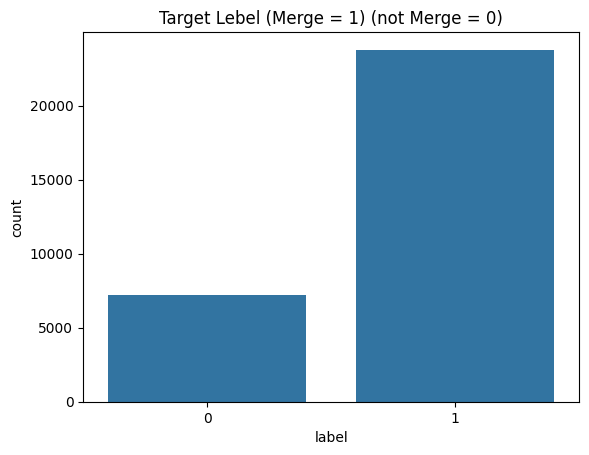

In [132]:
## target columns
sns.countplot(data=df , x = 'label')
plt.title("Target Lebel (Merge = 1) (not Merge = 0)")
plt.show()

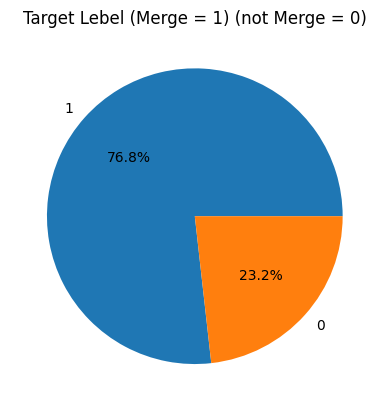

In [133]:
data = df['label'].value_counts()/df['label'].count()*100
plt.title("Target Lebel (Merge = 1) (not Merge = 0)")
plt.pie(data,labels=data.index , autopct='%1.1f%%')
plt.show()
## a moderate class imbalance

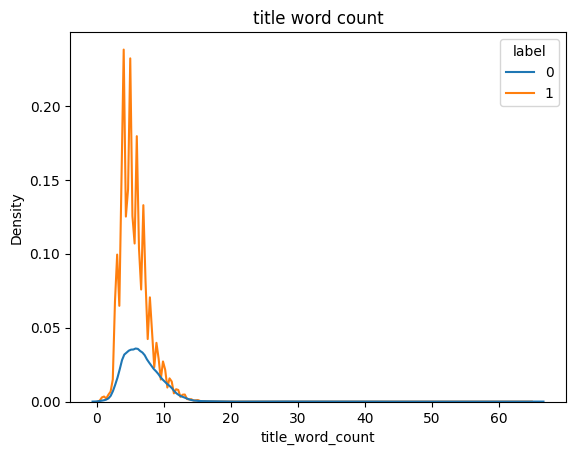

In [134]:
## title_word_count
sns.kdeplot(data=df , x = "title_word_count" ,hue='label')
plt.title('title word count')
plt.show()

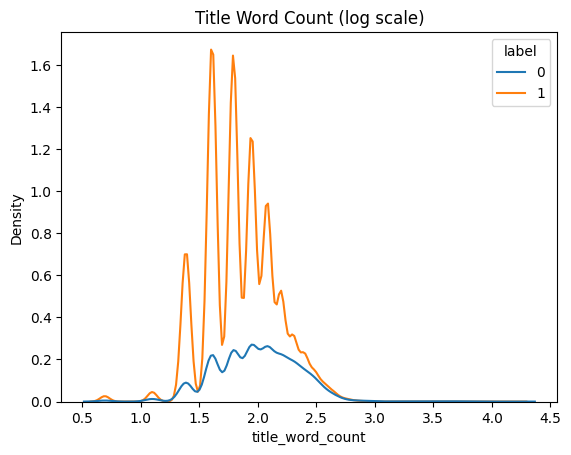

In [135]:
sns.kdeplot(data=df, x=np.log1p(df["title_word_count"]), hue='label')
plt.title('Title Word Count (log scale)')
plt.show()

In [136]:
# ─────────────────────────────────────────────────────────────────
# EDA Observation: title_word_count
# ─────────────────────────────────────────────────────────────────
# - Right-skewed distribution: most PR titles are short (3-7 words)
# - 75th percentile = 7 words; long tail extends up to ~65 words (rare)
# - Tree-based models (RF, XGBoost) handle this skew fine, no transform needed
# - For linear models, consider log1p transform: np.log1p(title_word_count)
# ─────────────────────────────────────────────────────────────────

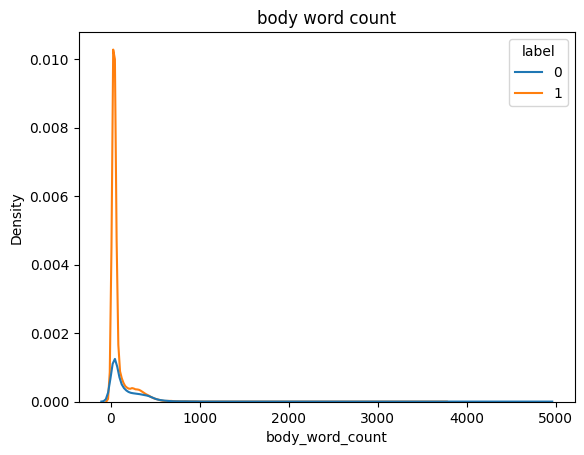

In [137]:
## body_word_count
sns.kdeplot(data=df , x = "body_word_count" , hue='label')
plt.title('body word count')
plt.show()
# ─────────────────────────────────────────────────────────────────
# EDA Observation: body_word_count
# ─────────────────────────────────────────────────────────────────
# - Extremely right-skewed: large spike near 0 (empty/very short bodies)
# - Long tail extends to ~5000 words (rare, likely auto-generated detailed PRs)
# - Confirms need for body_is_empty flag, since many bodies are near-empty
# - Tree-based models handle this fine; for linear models, use log1p transform
# - May need to cap/clip extreme outliers (e.g. >1000 words) before modeling
# ─────────────────────────────────────────────────────────────────

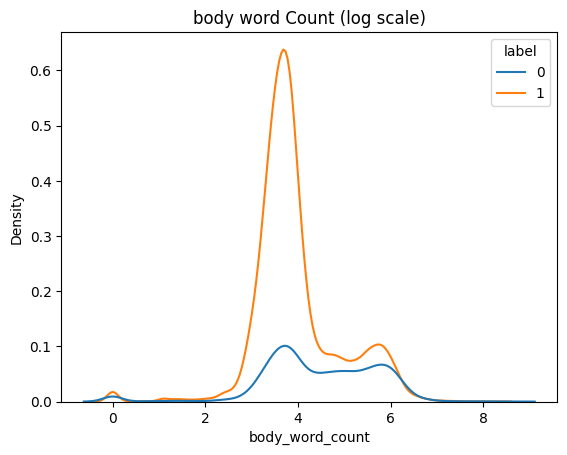

In [138]:
sns.kdeplot(data=df, x=np.log1p(df["body_word_count"]), hue='label')
plt.title('body word Count (log scale)')
plt.show()

count    3.098000e+04
mean     1.132417e+03
std      1.085353e+04
min      0.000000e+00
25%      1.700000e+01
50%      6.900000e+01
75%      2.360000e+02
max      1.053409e+06
Name: total_lines_added, dtype: float64


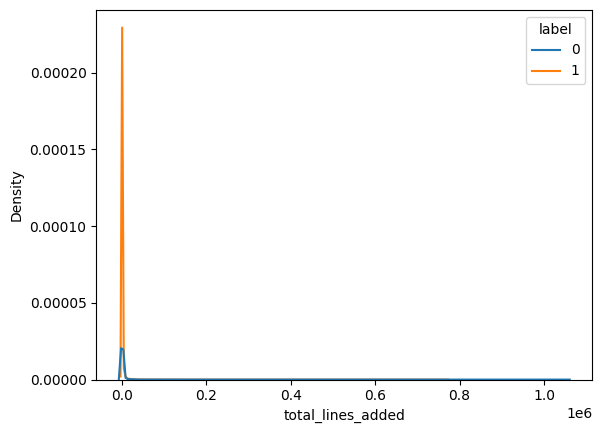

In [139]:
sns.kdeplot(df,x='total_lines_added'  , hue='label')
print(df['total_lines_added'].describe())
# ─────────────────────────────────────────────────────────────────
# EDA Observation: total_lines_added
# ─────────────────────────────────────────────────────────────────
# - Extremely right-skewed: 75th percentile = 234, but max = ~1,053,409
# - A few extreme outliers (likely vendor/generated files) dominate the scale
# - Raw histogram unusable; use log1p transform for visualization
# - Consider clipping/capping outliers before modeling, or rely on
#   tree-based models which are robust to such skew
# ─────────────────────────────────────────────────────────────────

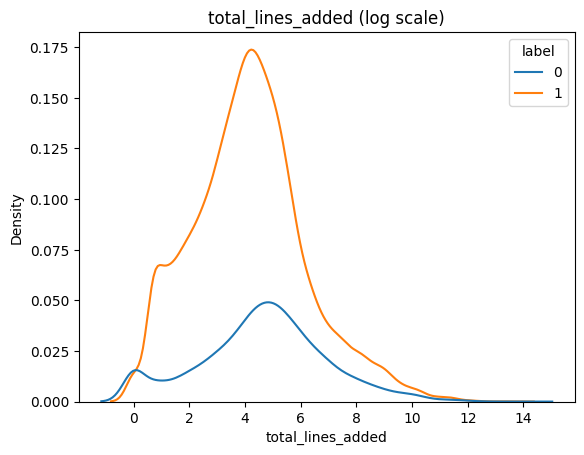

In [140]:
sns.kdeplot(data=df, x=np.log1p(df["total_lines_added"]), hue='label')
plt.title('total_lines_added (log scale)')
plt.show()

In [141]:
df['total_lines_added'].describe()

count    3.098000e+04
mean     1.132417e+03
std      1.085353e+04
min      0.000000e+00
25%      1.700000e+01
50%      6.900000e+01
75%      2.360000e+02
max      1.053409e+06
Name: total_lines_added, dtype: float64

In [142]:
df.describe()

,label,title_word_count,body_word_count,total_lines_added,total_lines_deleted,total_lines_changed,total_files_touched,files_added,files_modified,files_deleted,total_commits,stars,forks
count,30980.000000,30980.000000,30980.000000,3.098000e+04,30980.000000,3.098000e+04,30980.000000,30980.000000,30980.000000,30980.0,30980.000000,30980.000000,30980.000000
mean,0.767786,5.957715,101.652647,1.132417e+03,570.103292,1.702520e+03,16.043673,5.020949,12.717915,0.0,2.524984,4643.454132,748.609555
std,0.422252,2.464157,150.050187,1.085353e+04,8144.806828,1.608634e+04,50.331354,23.897279,44.773162,0.0,3.858708,16718.589863,3338.246139
min,0.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.0,1.000000,101.000000,1.000000
25%,1.000000,4.000000,32.000000,1.700000e+01,1.000000,2.500000e+01,1.000000,0.000000,1.000000,0.0,1.000000,251.000000,13.000000
50%,1.000000,5.000000,44.000000,6.900000e+01,9.000000,9.000000e+01,3.000000,0.000000,3.000000,0.0,1.000000,306.000000,58.000000
75%,1.000000,7.000000,100.000000,2.360000e+02,60.250000,3.260000e+02,8.000000,2.000000,7.000000,0.0,2.000000,1096.000000,210.000000
max,1.000000,65.000000,4854.000000,1.053409e+06,725881.000000,1.451946e+06,1641.000000,768.000000,2126.000000,0.0,30.000000,177379.000000,62633.000000


count     30980.000000
mean        570.103292
std        8144.806828
min           0.000000
25%           1.000000
50%           9.000000
75%          60.250000
max      725881.000000
Name: total_lines_deleted, dtype: float64


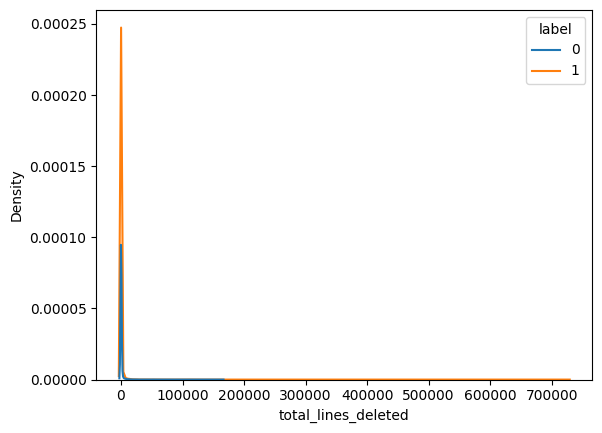

In [143]:
sns.kdeplot(df,x='total_lines_deleted' , hue='label')
print(df['total_lines_deleted'].describe())

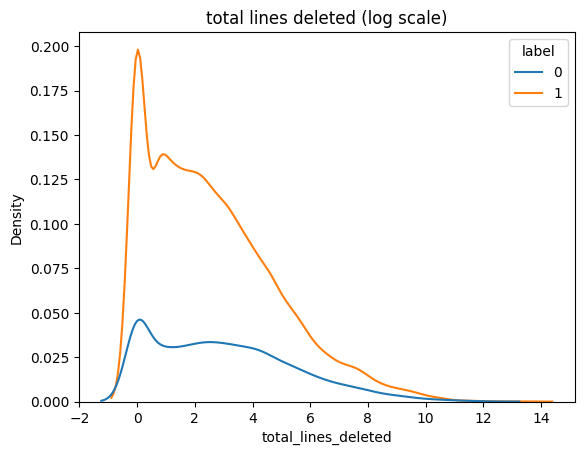

In [144]:
sns.kdeplot(data=df, x=np.log1p(df["total_lines_deleted"]), hue='label')
plt.title('total lines deleted (log scale)')
plt.show()

count    3.098000e+04
mean     1.702520e+03
std      1.608634e+04
min      0.000000e+00
25%      2.500000e+01
50%      9.000000e+01
75%      3.260000e+02
max      1.451946e+06
Name: total_lines_changed, dtype: float64


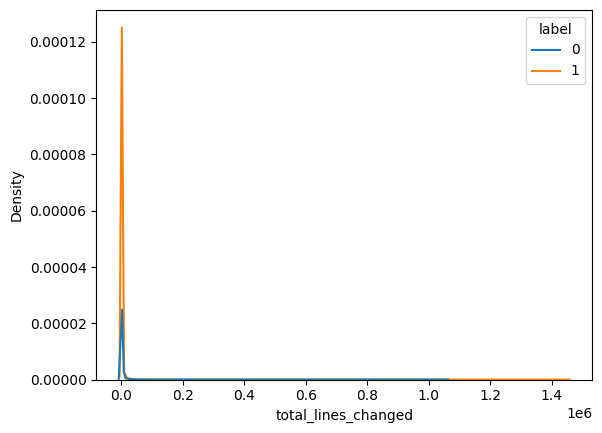

In [145]:
sns.kdeplot(df,x='total_lines_changed', hue='label' )
print(df['total_lines_changed'].describe())

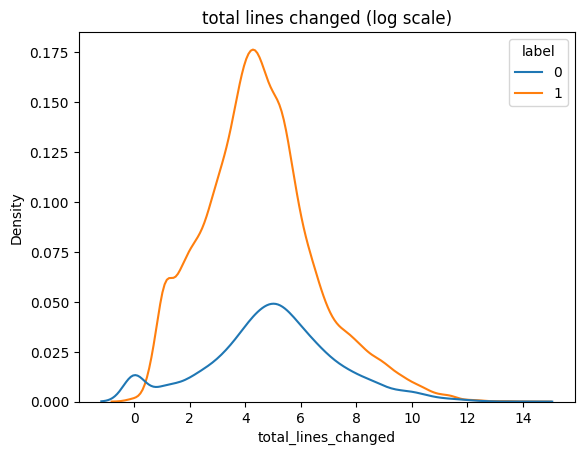

In [146]:
sns.kdeplot(data=df, x=np.log1p(df["total_lines_changed"]), hue='label')
plt.title('total lines changed (log scale)')
plt.show()

count    30980.000000
mean        16.043673
std         50.331354
min          0.000000
25%          1.000000
50%          3.000000
75%          8.000000
max       1641.000000
Name: total_files_touched, dtype: float64


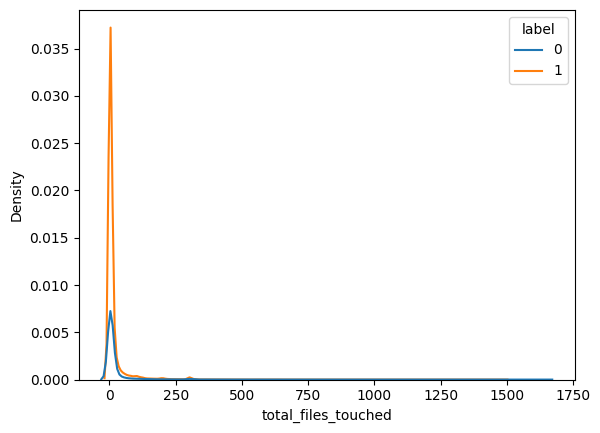

In [147]:
sns.kdeplot(df,x='total_files_touched' , hue='label')
print(df['total_files_touched'].describe())

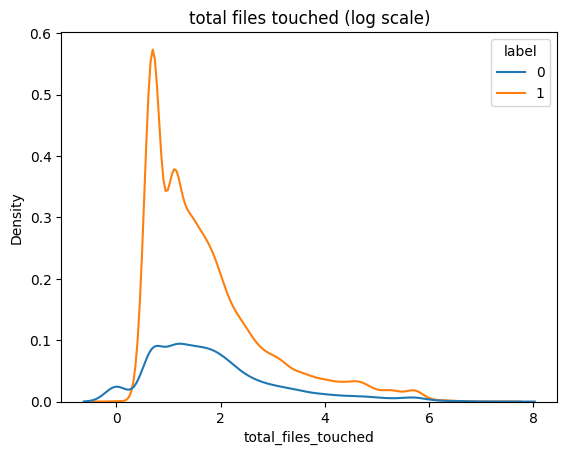

In [148]:
sns.kdeplot(data=df, x=np.log1p(df["total_files_touched"]), hue='label')
plt.title('total files touched (log scale)')
plt.show()

count    30980.000000
mean         5.020949
std         23.897279
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        768.000000
Name: files_added, dtype: float64


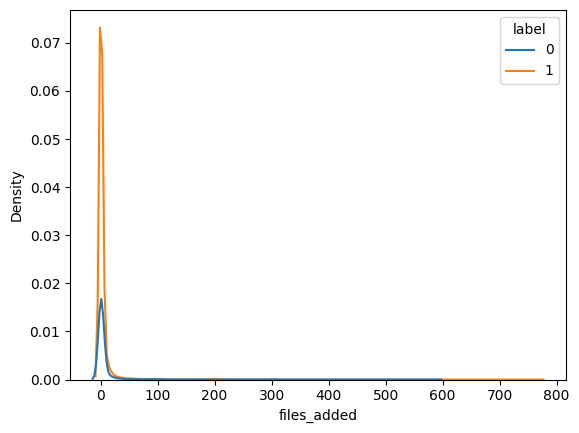

In [149]:
sns.kdeplot(df,x='files_added' , hue='label')
print(df['files_added'].describe())

count    30980.000000
mean         5.020949
std         23.897279
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        768.000000
Name: files_added, dtype: float64


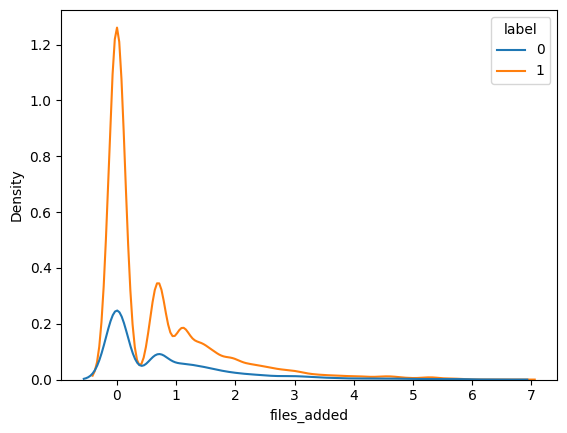

In [150]:
sns.kdeplot(df,x=np.log1p(df['files_added']), hue='label')
print(df['files_added'].describe())

count    30980.000000
mean        12.717915
std         44.773162
min          0.000000
25%          1.000000
50%          3.000000
75%          7.000000
max       2126.000000
Name: files_modified, dtype: float64


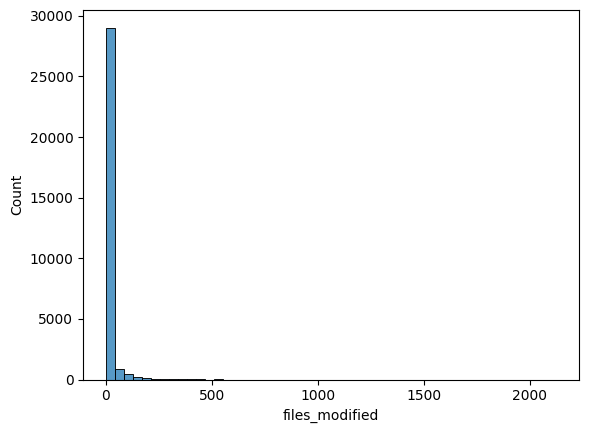

In [151]:
sns.histplot(df,x='files_modified' , bins=50)
print(df['files_modified'].describe())

In [152]:
df.describe()

,label,title_word_count,body_word_count,total_lines_added,total_lines_deleted,total_lines_changed,total_files_touched,files_added,files_modified,files_deleted,total_commits,stars,forks
count,30980.000000,30980.000000,30980.000000,3.098000e+04,30980.000000,3.098000e+04,30980.000000,30980.000000,30980.000000,30980.0,30980.000000,30980.000000,30980.000000
mean,0.767786,5.957715,101.652647,1.132417e+03,570.103292,1.702520e+03,16.043673,5.020949,12.717915,0.0,2.524984,4643.454132,748.609555
std,0.422252,2.464157,150.050187,1.085353e+04,8144.806828,1.608634e+04,50.331354,23.897279,44.773162,0.0,3.858708,16718.589863,3338.246139
min,0.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.0,1.000000,101.000000,1.000000
25%,1.000000,4.000000,32.000000,1.700000e+01,1.000000,2.500000e+01,1.000000,0.000000,1.000000,0.0,1.000000,251.000000,13.000000
50%,1.000000,5.000000,44.000000,6.900000e+01,9.000000,9.000000e+01,3.000000,0.000000,3.000000,0.0,1.000000,306.000000,58.000000
75%,1.000000,7.000000,100.000000,2.360000e+02,60.250000,3.260000e+02,8.000000,2.000000,7.000000,0.0,2.000000,1096.000000,210.000000
max,1.000000,65.000000,4854.000000,1.053409e+06,725881.000000,1.451946e+06,1641.000000,768.000000,2126.000000,0.0,30.000000,177379.000000,62633.000000


count    30980.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: files_deleted, dtype: float64


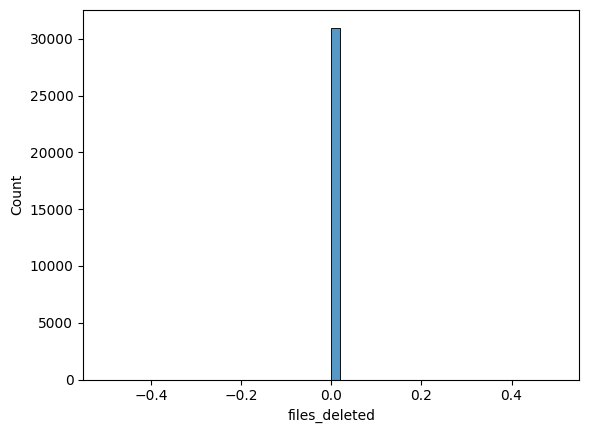

In [153]:
sns.histplot(df,x='files_deleted' , bins=50)
print(df['files_deleted'].describe())

count    30980.000000
mean         2.524984
std          3.858708
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         30.000000
Name: total_commits, dtype: float64


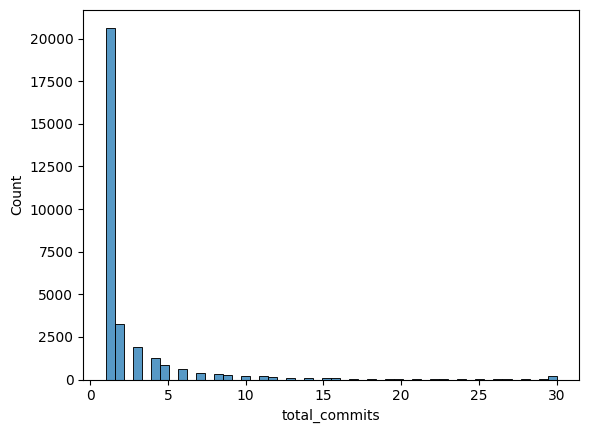

In [154]:
sns.histplot(df,x='total_commits' , bins=50)
print(df['total_commits'].describe())

count     30980.000000
mean       4643.454132
std       16718.589863
min         101.000000
25%         251.000000
50%         306.000000
75%        1096.000000
max      177379.000000
Name: stars, dtype: float64


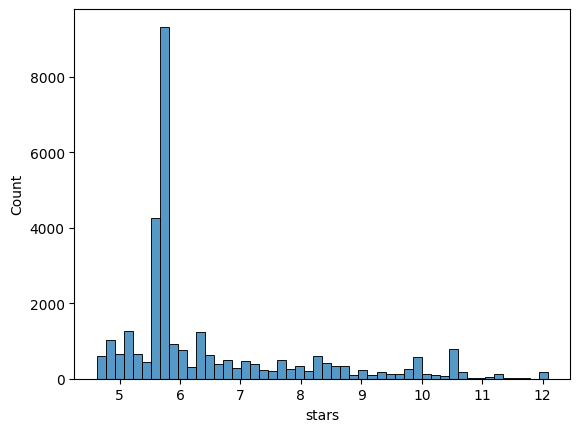

In [155]:
sns.histplot(df,x=np.log1p(df['stars']) , bins=50)
print(df['stars'].describe())

count    30980.000000
mean       748.609555
std       3338.246139
min          1.000000
25%         13.000000
50%         58.000000
75%        210.000000
max      62633.000000
Name: forks, dtype: float64


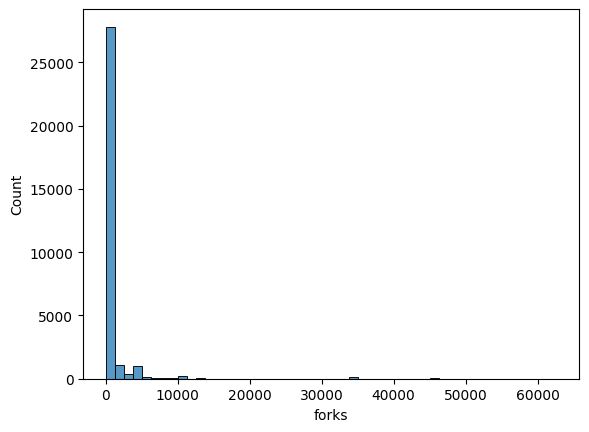

In [156]:
sns.histplot(df,x='forks' , bins=50)
print(df['forks'].describe())

count    30980.000000
mean       748.609555
std       3338.246139
min          1.000000
25%         13.000000
50%         58.000000
75%        210.000000
max      62633.000000
Name: forks, dtype: float64


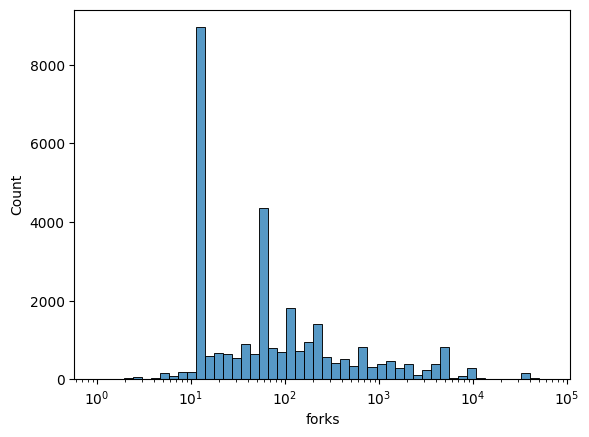

In [157]:
sns.histplot(df,x='forks' , bins=50 , log_scale=True)
print(df['forks'].describe())

In [158]:
df

,agent,label,title_word_count,body_word_count,total_lines_added,total_lines_deleted,total_lines_changed,total_files_touched,files_added,files_modified,files_deleted,total_commits,task_type,stars,forks,language
0,Claude_Code,0,12,256,394.0,2.0,396.0,3.0,1.0,2.0,0.0,1.0,fix,1230,368,Python
1,Claude_Code,1,1,49,38.0,38.0,76.0,11.0,0.0,11.0,0.0,1.0,refactor,391,21,TypeScript
2,Claude_Code,1,7,554,298.0,109.0,407.0,5.0,1.0,8.0,0.0,6.0,feat,505,19,Swift
3,Claude_Code,1,8,312,288.0,12.0,300.0,15.0,13.0,5.0,0.0,3.0,feat,367,90,TypeScript
4,Claude_Code,0,7,459,13214.0,2497.0,15711.0,94.0,73.0,68.0,0.0,5.0,chore,4630,617,TypeScript
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31279,Devin,1,9,125,64.0,21.0,85.0,2.0,0.0,9.0,0.0,6.0,fix,119,19,JavaScript
31280,Devin,0,7,40,43.0,4.0,47.0,1.0,0.0,2.0,0.0,2.0,docs,35096,4696,Python
31281,Devin,0,6,99,12.0,2.0,14.0,1.0,0.0,1.0,0.0,1.0,fix,428,93,C
31282,Devin,1,4,94,534.0,102.0,636.0,23.0,2.0,32.0,0.0,12.0,docs,798,255,TypeScript


In [159]:
df['language'].value_counts()

language
Go              9791
Python          6685
TypeScript      5933
C#              1751
Java            1186
                ... 
Fortran            1
CoffeeScript       1
Mustache           1
Jsonnet            1
Nushell            1
Name: count, Length: 78, dtype: int64

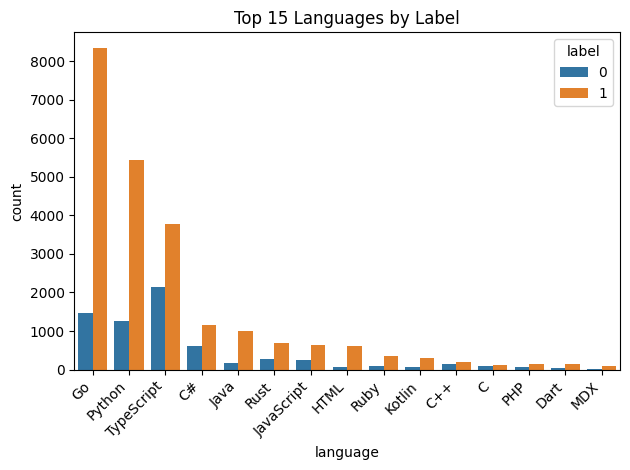

In [160]:
order = df['language'].value_counts().nlargest(15).index

sns.countplot(data=df, x='language', hue='label', order=order)
plt.xticks(rotation=45, ha='right')
plt.title('Top 15 Languages by Label')
plt.tight_layout()
plt.show()

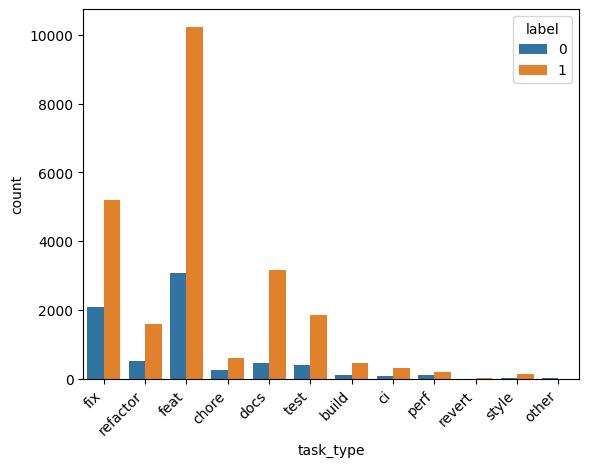

In [161]:
sns.countplot(data=df , x='task_type',hue='label')
plt.xticks(rotation=45, ha='right')
plt.show()

<Axes: xlabel='agent', ylabel='count'>

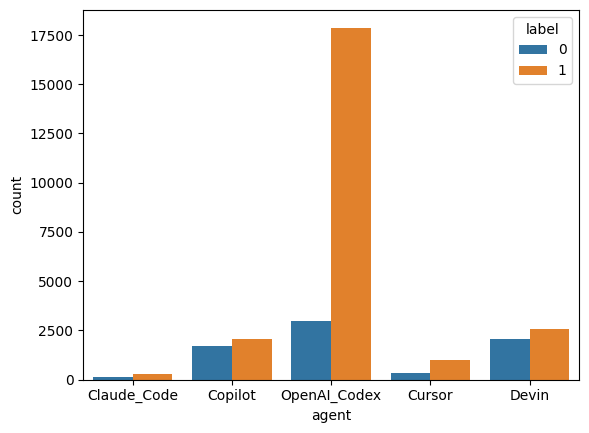

In [162]:
sns.countplot(data=df,x='agent',hue='label')

preprocessor pipeline

In [163]:
df

,agent,label,title_word_count,body_word_count,total_lines_added,total_lines_deleted,total_lines_changed,total_files_touched,files_added,files_modified,files_deleted,total_commits,task_type,stars,forks,language
0,Claude_Code,0,12,256,394.0,2.0,396.0,3.0,1.0,2.0,0.0,1.0,fix,1230,368,Python
1,Claude_Code,1,1,49,38.0,38.0,76.0,11.0,0.0,11.0,0.0,1.0,refactor,391,21,TypeScript
2,Claude_Code,1,7,554,298.0,109.0,407.0,5.0,1.0,8.0,0.0,6.0,feat,505,19,Swift
3,Claude_Code,1,8,312,288.0,12.0,300.0,15.0,13.0,5.0,0.0,3.0,feat,367,90,TypeScript
4,Claude_Code,0,7,459,13214.0,2497.0,15711.0,94.0,73.0,68.0,0.0,5.0,chore,4630,617,TypeScript
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31279,Devin,1,9,125,64.0,21.0,85.0,2.0,0.0,9.0,0.0,6.0,fix,119,19,JavaScript
31280,Devin,0,7,40,43.0,4.0,47.0,1.0,0.0,2.0,0.0,2.0,docs,35096,4696,Python
31281,Devin,0,6,99,12.0,2.0,14.0,1.0,0.0,1.0,0.0,1.0,fix,428,93,C
31282,Devin,1,4,94,534.0,102.0,636.0,23.0,2.0,32.0,0.0,12.0,docs,798,255,TypeScript


In [164]:
X = df.drop('label',axis=1)
y= df['label']

In [165]:
numeric_col =['title_word_count', 'body_word_count', 'total_lines_added',
       'total_lines_deleted', 'total_lines_changed', 'total_files_touched',
       'files_added', 'files_modified', 'files_deleted', 'total_commits',
       'stars', 'forks']
numeric_col

['title_word_count',
 'body_word_count',
 'total_lines_added',
 'total_lines_deleted',
 'total_lines_changed',
 'total_files_touched',
 'files_added',
 'files_modified',
 'files_deleted',
 'total_commits',
 'stars',
 'forks']

In [166]:
categorical_col = ['agent', 'task_type', 'language']
categorical_col

['agent', 'task_type', 'language']

In [167]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [168]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [169]:
p1 = Pipeline(
    steps=[
        ('inputer',SimpleImputer(strategy='median')),
        ('scaler',RobustScaler())
    ]
)

In [170]:
p2 = Pipeline(
    steps=[
        ('inputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder(handle_unknown='ignore',drop='first',sparse_output=False))
    ]
)

In [171]:
preprocessor = ColumnTransformer([
    ('num', p1, numeric_col),
    ('cat', p2, categorical_col)
])
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [172]:
from sklearn.metrics import classification_report


from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'KNN': KNeighborsClassifier(
        n_neighbors=5
    ),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=10,
        class_weight='balanced',
        random_state=42
    ),

    'SGD Classifier': SGDClassifier(
        loss='log_loss',
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    )
}

results = {}

for name, clf in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', clf)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    results[name] = pipeline.score(X_test, y_test)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))

# Summary
for name, score in results.items():
    print(f"{name}: {score:.4f}")


Logistic Regression
              precision    recall  f1-score   support

           0       0.43      0.59      0.49      2377
           1       0.86      0.76      0.81      7847

    accuracy                           0.72     10224
   macro avg       0.64      0.67      0.65     10224
weighted avg       0.76      0.72      0.73     10224


Random Forest
              precision    recall  f1-score   support

           0       0.74      0.36      0.49      2377
           1       0.83      0.96      0.89      7847

    accuracy                           0.82     10224
   macro avg       0.79      0.66      0.69     10224
weighted avg       0.81      0.82      0.80     10224


KNN
              precision    recall  f1-score   support

           0       0.57      0.34      0.43      2377
           1       0.82      0.92      0.87      7847

    accuracy                           0.79     10224
   macro avg       0.70      0.63      0.65     10224
weighted avg       0.76      0.79

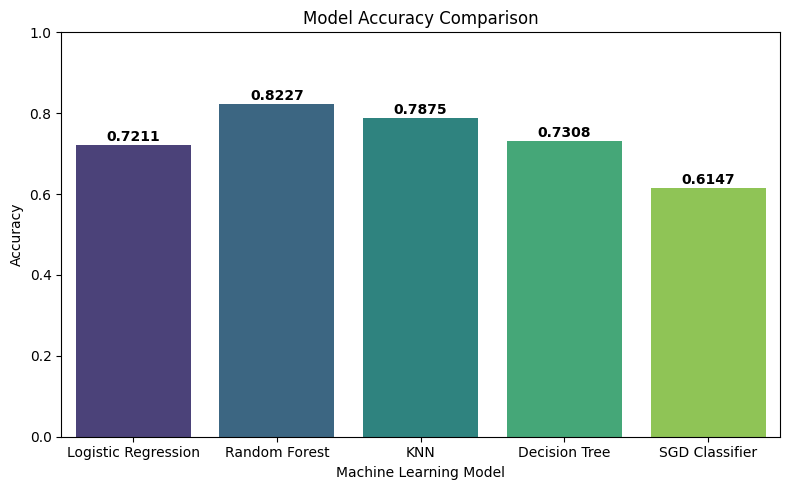

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

# Accuracy comparison plot
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=list(results.keys()),
    y=list(results.values()),
    hue=list(results.keys()),
    palette="viridis",
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

# Display accuracy above each bar
for index, score in enumerate(results.values()):
    ax.text(
        index,
        score + 0.01,
        f"{score:.4f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()